In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
import urllib.request
 
URL = "https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt"
 
with urllib.request.urlopen(URL) as response:
    text = response.read().decode("utf-8")
 
words = [line.strip() for line in text.splitlines() if line.strip()]


In [3]:
import random
random.seed(42)
random.shuffle(words)

In [4]:
NUM_LETTERS = 26
NUM_SPECIAL = 1
NUM_TOKENS = NUM_LETTERS + NUM_SPECIAL

alphabet = list(bytes([list('a'.encode("utf-8"))[0] + i for i in range(NUM_LETTERS)]).decode('utf-8'))

stoi = {
    ".": 0
}
itos = {
    0: "."
}
for i, s in enumerate(alphabet):
    stoi[s] = i + 1
    itos[i + 1] = s

itos

{0: '.',
 1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z'}

In [5]:
import random
CONTEXT_SIZE = 8

def build_dataset(words):
    X, Y = [], []

    for w in words:
        w = w.lower()
        context = [0] * CONTEXT_SIZE
        for s in w + ".":
            i = stoi[s]
            X.append(context)
            Y.append(i)
            context = context[1:] + [i]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)

    return X, Y

random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

# split the dataset into training, validation (dev) and test sets
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 8]) torch.Size([182580])
torch.Size([22767, 8]) torch.Size([22767])
torch.Size([22799, 8]) torch.Size([22799])


In [6]:
torch.manual_seed(42);

In [7]:
EMBEDDING_SIZE = 10
NUM_HIDDED_NEURONS = 200

model = torch.nn.Sequential(
    torch.nn.Embedding(NUM_TOKENS, EMBEDDING_SIZE), # emb = C[Xb] where C = torch.randn((NUM_TOKENS, EMBEDDING_SIZE))
    torch.nn.Flatten(),                             # x = emb.view(-1, CONTEXT_SIZE * EMBEDDING_SIZE)
    torch.nn.Linear(EMBEDDING_SIZE * CONTEXT_SIZE, NUM_HIDDED_NEURONS, bias=False), torch.nn.BatchNorm1d(NUM_HIDDED_NEURONS), torch.nn.Tanh(),
    torch.nn.Linear(NUM_HIDDED_NEURONS, NUM_TOKENS)
)

with torch.no_grad():
    # make the last layer less confidently wrong
    model[-1].weight *= 0.1

parameters = list(model.parameters())
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

22097


In [8]:

TRAINING_STEPS = 200_000
BATCH_SIZE = 100

lossi = []
for i in range(TRAINING_STEPS):
    # minibatch
    idx = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ))
    Xb, Yb = Xtr[idx], Ytr[idx]

    # forward
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150_000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # stats
    if i % 10_000 == 0:
        print(f"{i:7d}/{TRAINING_STEPS:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())

      0/ 200000: 3.2894


  10000/ 200000: 2.1443
  20000/ 200000: 2.0840
  30000/ 200000: 1.8964
  40000/ 200000: 1.8348
  50000/ 200000: 1.8048
  60000/ 200000: 1.9926
  70000/ 200000: 2.0830
  80000/ 200000: 1.9379
  90000/ 200000: 1.9043
 100000/ 200000: 2.0672
 110000/ 200000: 1.8732
 120000/ 200000: 1.8900
 130000/ 200000: 1.9211
 140000/ 200000: 1.9555
 150000/ 200000: 1.9159
 160000/ 200000: 2.0321
 170000/ 200000: 1.7711
 180000/ 200000: 1.9239
 190000/ 200000: 2.0500


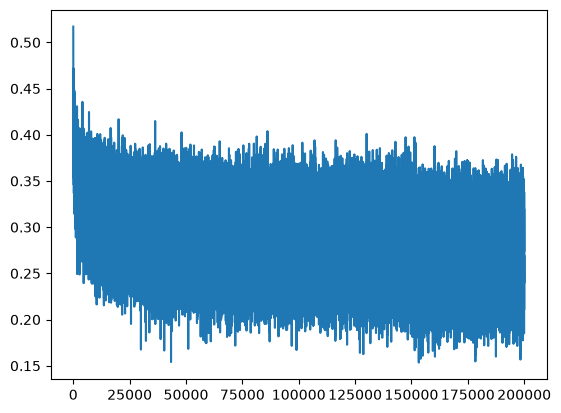

In [9]:
plt.plot(lossi)

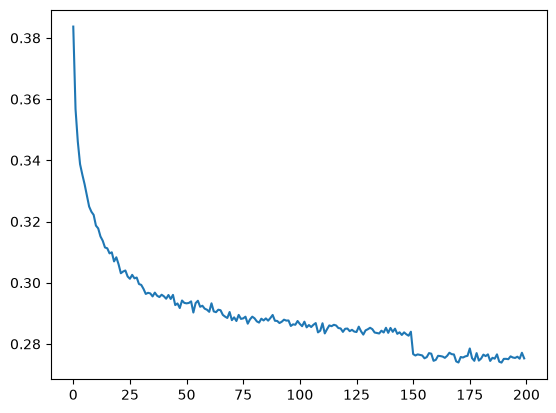

In [10]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [11]:
# eval mode
model.eval()

Sequential(
  (0): Embedding(27, 10)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=80, out_features=200, bias=False)
  (3): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (4): Tanh()
  (5): Linear(in_features=200, out_features=27, bias=True)
)

In [12]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.8645944595336914
val 2.030383825302124


In [13]:
# Sampling from the model
for _ in range(20):
    word = ""
    context = [0] * CONTEXT_SIZE
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        word += itos[ix]
        context = context[1:] + [ix]
        if ix == 0:
            break

    print(word)

krodre.
avahi.
veronie.
rosa.
aisai.
hinga.
graylin.
cashiel.
lole.
aryima.
chelsi.
sandy.
ayali.
xzavi.
kalayne.
mazaika.
evelino.
vanvi.
kamyra.
eliorgan.


In [14]:
# one architectural bottleneck to the performance of the network is due to the fact that we are cramming too much information into the first layer (all the characters in the context of size CONTEXT_SIZE)
# a better way is to follow the Wavenet architecture where tokens are paired together in the first layer and get combined with other pairs in later layers
# to do this, instead of concatenating all the tokens into a single input to the first layer, we pair tokens in the context window resulting in 4 pairs of 2 10-dimensional embeddings
# instead of a Flatten layer, we need to use a different layer that from an input of (Xb, 8, 10) outputs a (Xb, 4, 20) matrix
#
# Two pieces of this don't match PyTorch's built-ins, so we implement them as small
# nn.Modules that plug straight into nn.Sequential.


class FlettenConsecutive(torch.nn.Module):
    """Group every `n` consecutive time steps:  (B, T, C) -> (B, T // n, C * n).

    Replaces nn.Flatten. Instead of collapsing the entire context into the first
    layer, we merge tokens in pairs and let deeper layers merge the pairs. When the
    time dimension collapses to 1 (the final grouping) we squeeze it, so the tensor
    is 2D again -- ready for the output Linear and cross_entropy.
    """
    def __init__(self, n):
        super().__init__()
        self.n = n

    def forward(self, x):
        B, T, C = x.shape
        x = x.view(B, T // self.n, C * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        return x


class BatchNorm1d(torch.nn.Module):
    """BatchNorm that normalizes the LAST dimension (features-last layout).

    torch.nn.BatchNorm1d expects channels-first -- (N, C) or (N, C, L) -- and always
    normalizes dim 1, the convention it inherits from conv nets. Our activations are
    features-last, (B, T, C_feat), so the built-in normalizes the wrong axis (here it
    just errors). This version reduces over every dim except the last, so it handles
    both 2D (B, C) and 3D (B, T, C) inputs, pooling statistics over batch and time.
    """
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        super().__init__()
        self.eps = eps
        self.momentum = momentum
        self.gamma = torch.nn.Parameter(torch.ones(dim))
        self.beta = torch.nn.Parameter(torch.zeros(dim))
        # running stats are buffers, not parameters: they travel with the model
        # (save/load, .to(device)) but are not touched by the optimizer.
        self.register_buffer('running_mean', torch.zeros(dim))
        self.register_buffer('running_var', torch.ones(dim))

    def forward(self, x):
        if self.training:
            dims = tuple(range(x.dim() - 1))          # (0,) if 2D, (0, 1) if 3D
            mean = x.mean(dims, keepdim=True)
            var = x.var(dims, keepdim=True, unbiased=False)
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean.squeeze()
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var.squeeze()
        else:
            mean = self.running_mean
            var = self.running_var
        xhat = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * xhat + self.beta


In [15]:
EMBEDDING_SIZE = 10
NUM_HIDDED_NEURONS = 68

# Each block: group two neighbours (FlettenConsecutive) -> Linear -> BatchNorm -> Tanh.
# After the first grouping we combine embeddings (in = EMBEDDING_SIZE * 2); after that
# we combine hidden vectors (in = NUM_HIDDED_NEURONS * 2). The final grouping collapses
# time to 1, FlettenConsecutive squeezes it, and the output Linear maps to the vocab.
model = torch.nn.Sequential(
    torch.nn.Embedding(NUM_TOKENS, EMBEDDING_SIZE),                                                                                                     # (B, 8, 10)
    FlettenConsecutive(2), torch.nn.Linear(EMBEDDING_SIZE * 2,     NUM_HIDDED_NEURONS, bias=False), BatchNorm1d(NUM_HIDDED_NEURONS), torch.nn.Tanh(),   # (B, 4, 20)  -> (B, 4, 200)
    FlettenConsecutive(2), torch.nn.Linear(NUM_HIDDED_NEURONS * 2, NUM_HIDDED_NEURONS, bias=False), BatchNorm1d(NUM_HIDDED_NEURONS), torch.nn.Tanh(),   # (B, 2, 400) -> (B, 2, 200)
    FlettenConsecutive(2), torch.nn.Linear(NUM_HIDDED_NEURONS * 2, NUM_HIDDED_NEURONS, bias=False), BatchNorm1d(NUM_HIDDED_NEURONS), torch.nn.Tanh(),   # (B, 1, 400) -> squeeze -> (B, 200)
    torch.nn.Linear(NUM_HIDDED_NEURONS, NUM_TOKENS),                                                                                                    # (B, 27)
)

with torch.no_grad():
    # make the last layer less confidently wrong
    model[-1].weight *= 0.1

parameters = list(model.parameters())
print(sum(p.nelement() for p in parameters))   # 170897
for p in parameters:
    p.requires_grad = True


22397


In [16]:
TRAINING_STEPS = 200_000
BATCH_SIZE = 100

lossi = []
for i in range(TRAINING_STEPS):
    # minibatch
    idx = torch.randint(0, Xtr.shape[0], (BATCH_SIZE, ))
    Xb, Yb = Xtr[idx], Ytr[idx]

    # forward
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150_000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # stats
    if i % 10_000 == 0:
        print(f"{i:7d}/{TRAINING_STEPS:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())

      0/ 200000: 3.3162
  10000/ 200000: 2.2037
  20000/ 200000: 1.9623
  30000/ 200000: 2.0302
  40000/ 200000: 2.1435
  50000/ 200000: 2.1811
  60000/ 200000: 1.7514
  70000/ 200000: 1.9315
  80000/ 200000: 2.0767
  90000/ 200000: 2.0243
 100000/ 200000: 2.0281
 110000/ 200000: 2.0509
 120000/ 200000: 1.9021
 130000/ 200000: 1.8604
 140000/ 200000: 1.8445
 150000/ 200000: 1.9046
 160000/ 200000: 1.9143
 170000/ 200000: 1.7795
 180000/ 200000: 2.2416
 190000/ 200000: 1.7677


In [17]:
split_loss('train')
split_loss('val')

train 1.8422234058380127
val 2.022778034210205
